# DINOv3-L video-layer autocorrelation

This notebook selects one video from `~/Desktop/yes/`, extracts average-pooled activations from every DINOv3-L layer, computes the full frame-by-frame autocorrelation matrix for each layer using `TimeSeries`, and plots the matrices.

In [74]:
from pathlib import Path
import math
import sys

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor
from scipy.spatial.distance import squareform
from tqdm.auto import tqdm

USEFUL_SRC = Path('/Users/tizianocausin/Desktop/useful_stuff/python_scripts/src')
STATIC_SRC = Path('/Users/tizianocausin/Desktop/static_dynamic/python_scripts/src')
for src in (USEFUL_SRC, STATIC_SRC):
    if str(src) not in sys.path:
        sys.path.insert(0, str(src))

from useful_stuff.general_utils import TimeSeries
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.image_processing.computational_models import imgANN, get_relevant_output_layers

## Settings

Leave `VIDEO_PATH = None` to use the first supported video in `VIDEO_DIR`, or set it to a specific file.

In [113]:
VIDEO_DIR = Path('~/Desktop/yes').expanduser()
VIDEO_PATH = VIDEO_DIR / "wild_dramas_00_28_50__start_00.00.01.46__end_00.00.03.96__dur_00.00.02.5__crop_500px_to_500x500.mp4"  # Example: VIDEO_DIR / 'my_clip.mp4'

MODEL_NAME = 'dino_v3_l'
REPO_URL = 'facebook/dinov3-vitl16-pretrain-lvd1689m'

# Kept for imgANN compatibility. Actual frame preprocessing is controlled by the DINO image processor.
IMG_SIZE = 224
BATCH_SIZE = 8
FRAME_STRIDE = 1
MAX_FRAMES = None  # Set to an integer for quick tests; None uses the full video.
LAGPLOT_MAX_LAG = 300

# Multi-video RDM/dRSA section settings.
RDM_VIDEO_SUBSAMPLE_SIZE = 20
RDM_N_TIMEPOINTS = 75
RDM_RANDOM_SEED = 0
RDM_METRIC = 'cosine_cnt'
RDM_RSA_METRIC = 'correlation'

# Cross-layer comparison: source layers/timepoints against the final frame of this target layer.
CROSS_LAYER_TARGET_LAYER_INDEX = 16

OUTPUT_DIR = Path('dinov3_autocorr_outputs')

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

# float32 is slower than float16 but is safer across CPU/MPS/CUDA and for correlation math.
DTYPE = torch.float32

DEVICE

'mps'

In [69]:
def choose_video(video_dir, video_path=None):
    if video_path is not None:
        video_path = Path(video_path).expanduser()
        if not video_path.exists():
            raise FileNotFoundError(video_path)
        return video_path

    suffixes = {'.mp4', '.mov', '.m4v', '.avi', '.mkv'}
    videos = sorted(
        p for p in Path(video_dir).expanduser().iterdir()
        if p.is_file() and not p.name.startswith('.') and p.suffix.lower() in suffixes
    )
    if not videos:
        raise FileNotFoundError(f'No videos found in {video_dir}')
    return videos[0]


def read_video_frames(video_path, frame_stride=1, max_frames=None):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'Could not open video: {video_path}')

    fps = cap.get(cv2.CAP_PROP_FPS)
    if not fps or np.isnan(fps):
        fps = 30.0

    frames = []
    frame_idx = 0
    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break
            if frame_idx % frame_stride == 0:
                frames.append(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
                if max_frames is not None and len(frames) >= max_frames:
                    break
            frame_idx += 1
    finally:
        cap.release()

    if not frames:
        raise RuntimeError(f'No frames decoded from {video_path}')
    return frames, float(fps) / frame_stride


video_path = choose_video(VIDEO_DIR, VIDEO_PATH)
frames_rgb, sampling_rate = read_video_frames(video_path, FRAME_STRIDE, MAX_FRAMES)
print(f'Video: {video_path}')
print(f'Frames used: {len(frames_rgb)}')
print(f'Sampling rate after stride: {sampling_rate:.3f} Hz')
print(f'First frame shape: {frames_rgb[0].shape}')

Video: /Users/tizianocausin/Desktop/yes/wild_dramas_00_28_50__start_00.00.01.46__end_00.00.03.96__dur_00.00.02.5__crop_500px_to_500x500.mp4
Frames used: 62
Sampling rate after stride: 25.000 Hz
First frame shape: (500, 500, 3)


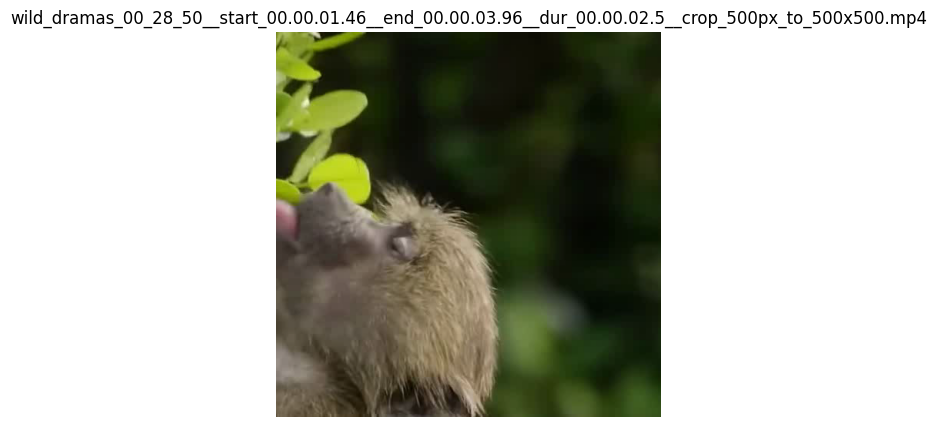

In [50]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(frames_rgb[0])
ax.set_title(video_path.name)
ax.axis('off');

## Extract average-pooled DINOv3-L features

The hook uses `pooling='mean'`, so token activations from each selected layer are average-pooled into one feature vector per frame.

In [56]:
image_processor = AutoImageProcessor.from_pretrained(REPO_URL)

layers = get_relevant_output_layers(MODEL_NAME, pkg='hf')
print(f'{len(layers)} layers')
print(image_processor)
layers[:3], layers[-3:]


24 layers
DINOv3ViTImageProcessorFast {
  "crop_size": null,
  "data_format": "channels_first",
  "default_to_square": true,
  "device": null,
  "disable_grouping": null,
  "do_center_crop": null,
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_pad": null,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "input_data_format": null,
  "pad_size": null,
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "return_tensors": null,
  "size": {
    "height": 224,
    "width": 224
  }
}



(['layer.0.mlp.down_proj', 'layer.1.mlp.down_proj', 'layer.2.mlp.down_proj'],
 ['layer.21.mlp.down_proj',
  'layer.22.mlp.down_proj',
  'layer.23.mlp.down_proj'])

In [57]:
ann = imgANN(
    model_name=MODEL_NAME,
    pkg='hf',
    img_size=IMG_SIZE,
    relevant_layers=layers,
    pooling='mean',
    dtype=DTYPE,
    attn_implementation='sdpa',
    repo_url=REPO_URL,
    device=DEVICE,
)
ann.model.eval()
ann.create_forward_hook(layers)

({},
 {'layer.0.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x31442d2b0>,
  'layer.1.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x3144e2690>,
  'layer.2.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x3143798b0>,
  'layer.3.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x31437af30>,
  'layer.4.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x314378350>,
  'layer.5.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x31437bfb0>,
  'layer.6.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x31437ae10>,
  'layer.7.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x314379b50>,
  'layer.8.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x31437be30>,
  'layer.9.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x31437be90>,
  'layer.10.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x31437bd70>,
  'layer.11.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x314378410>,
  'layer.12.mlp.down_proj': <torch.utils.hook

In [58]:
def batched(items, batch_size):
    for start in range(0, len(items), batch_size):
        yield start, items[start:start + batch_size]


features_by_layer = {layer: [] for layer in layers}

with torch.inference_mode():
    for _, batch_frames in tqdm(list(batched(frames_rgb, BATCH_SIZE)), desc='DINOv3-L batches'):
        inputs = image_processor(images=batch_frames, return_tensors='pt')
        batch = inputs['pixel_values'].to(DEVICE, dtype=DTYPE)

        # For HuggingFace ViT-style models, pass DINO-preprocessed pixel_values directly.
        _ = ann.model(pixel_values=batch)

        for layer in layers:
            layer_features = ann.features[layer]
            if layer_features is None:
                raise RuntimeError(f'Hook did not capture features for {layer}')
            features_by_layer[layer].append(layer_features.detach().float().cpu().numpy())
            ann.features[layer] = None

features_by_layer = {
    layer: np.concatenate(chunks, axis=0)
    for layer, chunks in features_by_layer.items()
}

print('Layer feature shapes:')
for layer, arr in list(features_by_layer.items())[:3]:
    print(layer, arr.shape)
print('...')
for layer, arr in list(features_by_layer.items())[-3:]:
    print(layer, arr.shape)

DINOv3-L batches:   0%|          | 0/8 [00:00<?, ?it/s]

Layer feature shapes:
layer.0.mlp.down_proj (62, 1024)
layer.1.mlp.down_proj (62, 1024)
layer.2.mlp.down_proj (62, 1024)
...
layer.21.mlp.down_proj (62, 1024)
layer.22.mlp.down_proj (62, 1024)
layer.23.mlp.down_proj (62, 1024)


## Compute full autocorrelation matrices

`TimeSeries` expects arrays as `features x time`, so each layer's `time x features` activation matrix is transposed before calling `.autocorr()`.

In [59]:
timeseries_by_layer = {}
autocorr_by_layer = {}
lagplot_by_layer = {}

for layer, feature_matrix in features_by_layer.items():
    ts = TimeSeries(feature_matrix.T, fs=sampling_rate)
    max_lag = max(1, min(LAGPLOT_MAX_LAG, len(ts) - 1))
    ac_mat, ac_decay = ts.autocorr(max_lag=max_lag)
    timeseries_by_layer[layer] = ts
    autocorr_by_layer[layer] = ac_mat
    lagplot_by_layer[layer] = ac_decay

example_layer = layers[-1]
print(example_layer, autocorr_by_layer[example_layer].shape, lagplot_by_layer[example_layer].shape)

15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of datapoints used to compute extreme offsets is < than 10
15:34:01 - The number of dat

## Plot all layer autocorrelation matrices

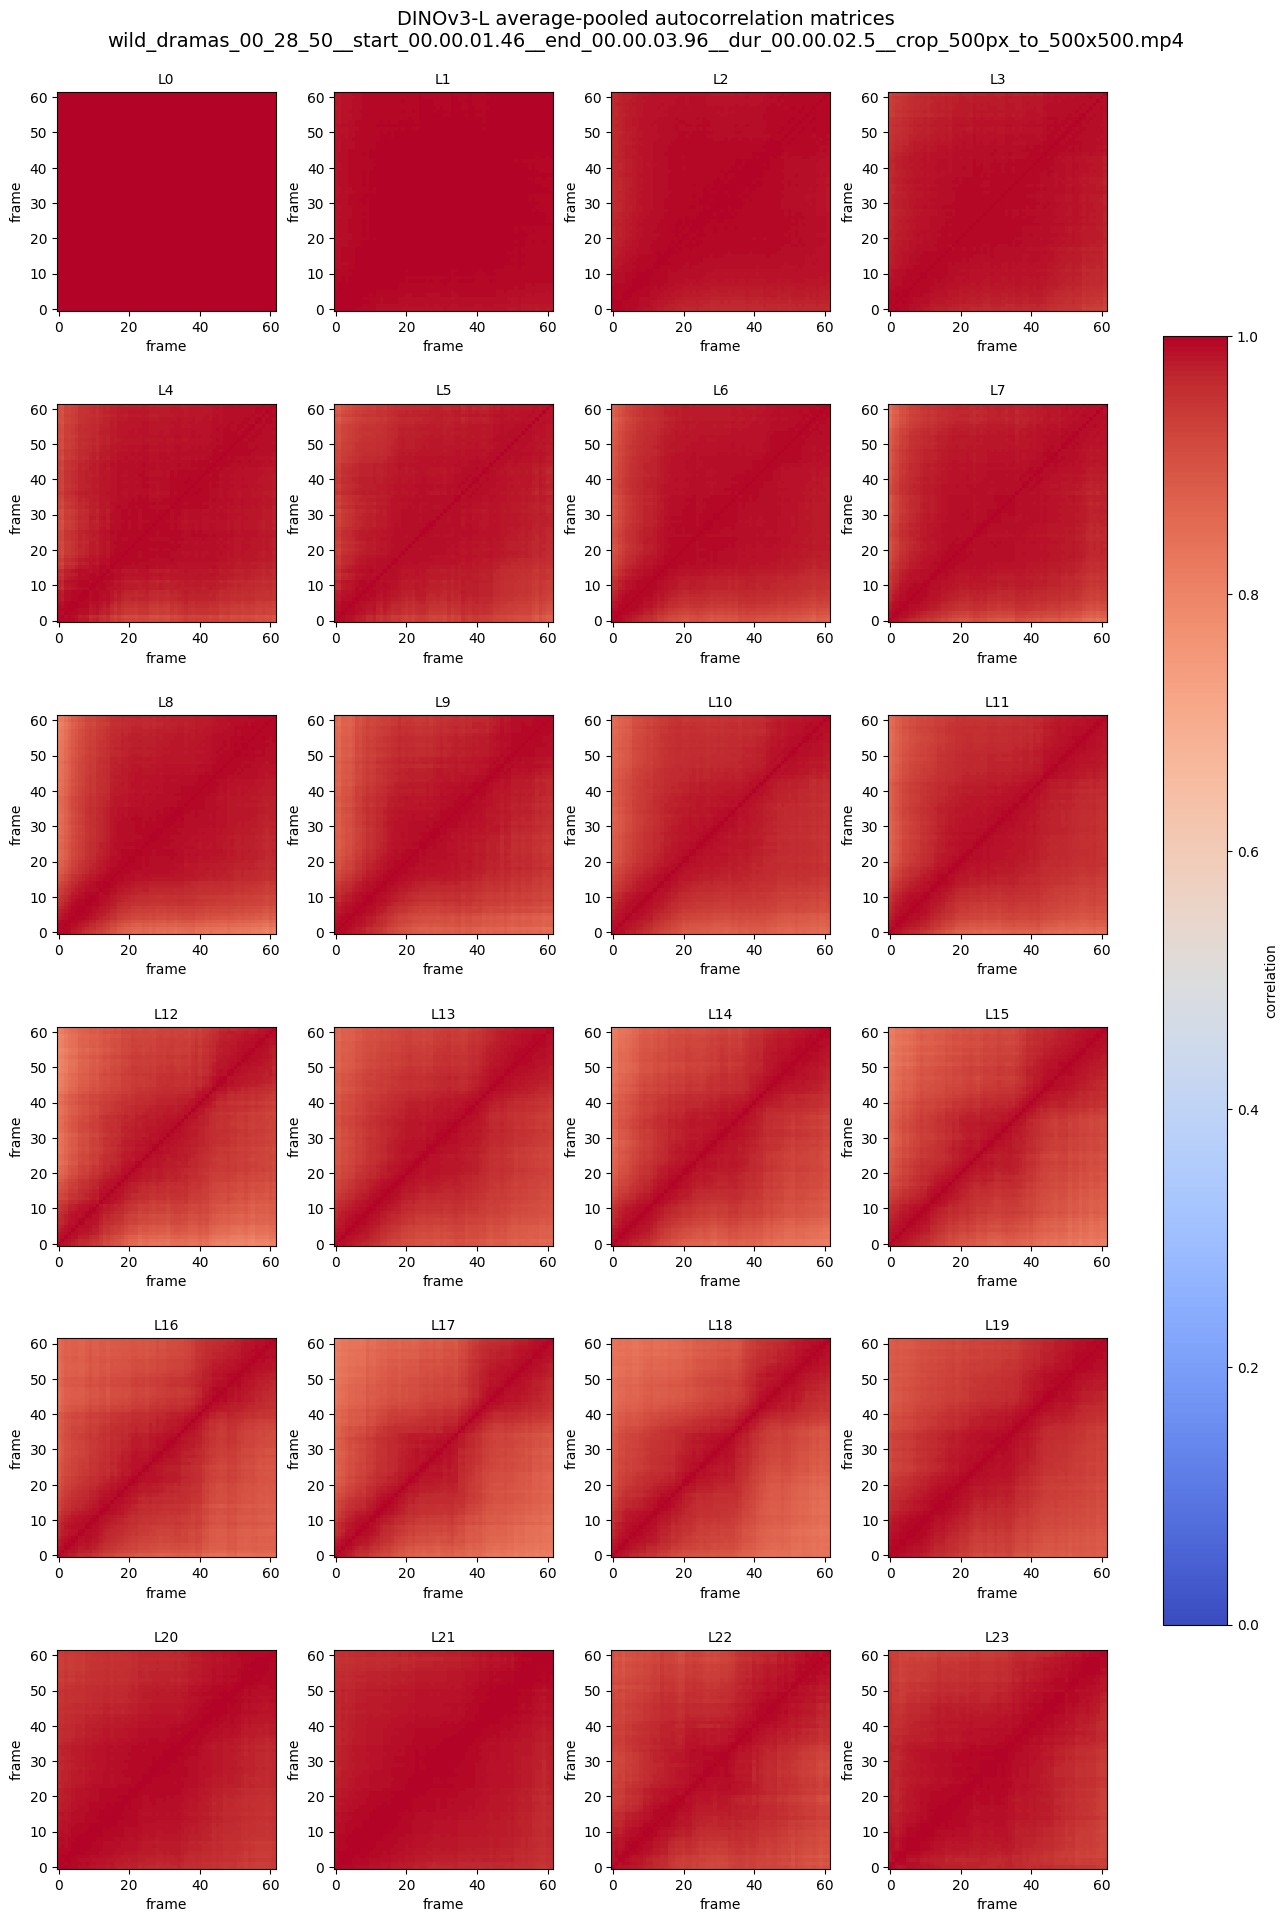

In [60]:
def short_layer_name(layer):
    return layer.replace('layer.', 'L').replace('.mlp.down_proj', '')


n_layers = len(layers)
ncols = 4
nrows = math.ceil(n_layers / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), constrained_layout=True)
axes = np.asarray(axes).ravel()

im = None
for ax, layer in zip(axes, layers):
    im = ax.imshow(autocorr_by_layer[layer], vmin=0, vmax=1, cmap='coolwarm', origin='lower')
    ax.set_title(short_layer_name(layer), fontsize=10)
    ax.set_xlabel('frame')
    ax.set_ylabel('frame')

for ax in axes[n_layers:]:
    ax.axis('off')

fig.suptitle(f'DINOv3-L average-pooled autocorrelation matrices\n{video_path.name}', fontsize=14)
fig.colorbar(im, ax=axes[:n_layers], shrink=0.7, label='correlation')
plt.show()

## Plot lag-decay curves

Each curve is the diagonal-averaged autocorrelation returned by `TimeSeries.autocorr()`, with layer color assigned from the `plasma` colormap.

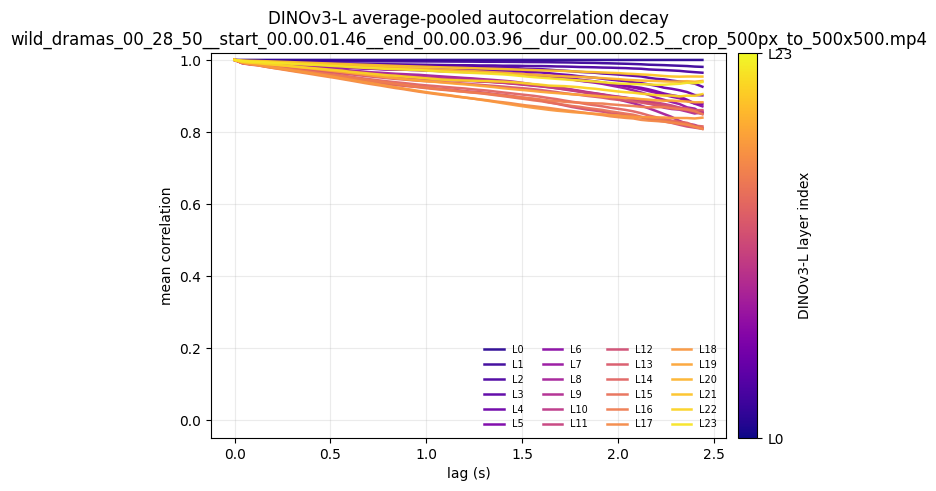

In [61]:
cmap = plt.cm.plasma
colors = cmap(np.linspace(0.05, 0.95, len(layers)))

fig, ax = plt.subplots(figsize=(8, 5))
for layer_idx, (layer, color) in enumerate(zip(layers, colors)):
    decay = lagplot_by_layer[layer]
    lag_seconds = np.arange(len(decay)) / sampling_rate
    ax.plot(
        lag_seconds,
        decay,
        color=color,
        linewidth=1.8,
        alpha=0.95,
        label=short_layer_name(layer),
    )

ax.set_title(f'DINOv3-L average-pooled autocorrelation decay\n{video_path.name}')
ax.set_xlabel('lag (s)')
ax.set_ylabel('mean correlation')
ax.set_ylim(-0.05, 1.02)
ax.grid(True, alpha=0.25)

norm = plt.Normalize(vmin=0, vmax=len(layers) - 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('DINOv3-L layer index')
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels([short_layer_name(layers[0]), short_layer_name(layers[-1])])

ax.legend(ncol=4, fontsize=7, frameon=False, loc='lower right')
plt.show()

## Correlation to the final frame

For each DINOv3-L layer, this computes the Pearson correlation between every frame feature vector and the feature vector of the last frame. The x-axis is time relative to the final frame.

In [64]:
def correlate_rows_to_reference(feature_matrix, reference_vector):
    x = np.asarray(feature_matrix, dtype=np.float64)
    ref = np.asarray(reference_vector, dtype=np.float64)

    x_centered = x - x.mean(axis=1, keepdims=True)
    ref_centered = ref - ref.mean()

    numerator = x_centered @ ref_centered
    denominator = np.linalg.norm(x_centered, axis=1) * np.linalg.norm(ref_centered)
    return np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan, dtype=np.float64),
        where=denominator > 0,
    )


corr_to_last_by_layer = {
    layer: correlate_rows_to_reference(feature_matrix, feature_matrix[-1])
    for layer, feature_matrix in features_by_layer.items()
}

n_frames = next(iter(features_by_layer.values())).shape[0]
frame_offsets_to_last = np.arange(n_frames) - (n_frames - 1)
time_offsets_to_last = frame_offsets_to_last / sampling_rate

example_layer = layers[-1]
print(example_layer, corr_to_last_by_layer[example_layer].shape)
print(f'Final-frame self-correlation: {corr_to_last_by_layer[example_layer][-1]:.3f}')


layer.23.mlp.down_proj (62,)
Final-frame self-correlation: 1.000


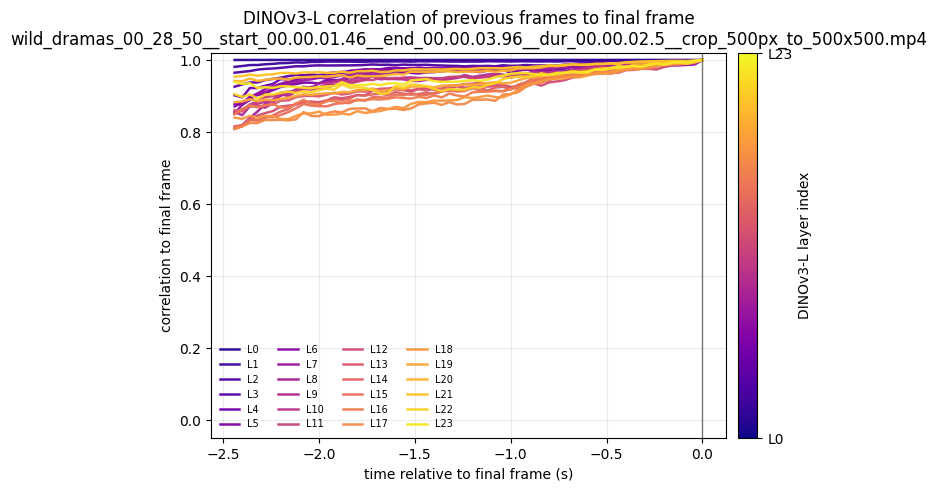

In [65]:
cmap = plt.cm.plasma
colors = cmap(np.linspace(0.05, 0.95, len(layers)))

fig, ax = plt.subplots(figsize=(8, 5))
for layer, color in zip(layers, colors):
    ax.plot(
        time_offsets_to_last,
        corr_to_last_by_layer[layer],
        color=color,
        linewidth=1.8,
        alpha=0.95,
        label=short_layer_name(layer),
    )

ax.axvline(0, color='black', linewidth=1, alpha=0.5)
ax.set_title(f'DINOv3-L correlation of previous frames to final frame\n{video_path.name}')
ax.set_xlabel('time relative to final frame (s)')
ax.set_ylabel('correlation to final frame')
ax.set_ylim(-0.05, 1.02)
ax.grid(True, alpha=0.25)

norm = plt.Normalize(vmin=0, vmax=len(layers) - 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('DINOv3-L layer index')
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels([short_layer_name(layers[0]), short_layer_name(layers[-1])])

ax.legend(ncol=4, fontsize=7, frameon=False, loc='lower left')
plt.show()


## Multi-video RDMs and final-frame dRSA

This section randomly samples videos from `VIDEO_DIR`, extracts DINOv3-L activations for uniformly spaced frames in each video, computes one RDM across videos at each time point for every layer using `dRSA`, and correlates each previous RDM with the final-frame RDM.

In [98]:
def list_video_paths(video_dir):
    suffixes = {'.mp4', '.mov', '.m4v', '.avi', '.mkv'}
    return sorted(
        p for p in Path(video_dir).expanduser().iterdir()
        if p.is_file() and not p.name.startswith('.') and p.suffix.lower() in suffixes
    )


def uniformly_sample_frames(frames, n_timepoints):
    if len(frames) == 0:
        raise RuntimeError('Cannot sample from an empty frame list')
    frame_idx = np.linspace(0, len(frames) - 1, n_timepoints).round().astype(int)
    return [frames[i] for i in frame_idx], frame_idx


def clear_model_cache():
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    elif DEVICE == 'mps':
        torch.mps.empty_cache()


def extract_dinov3_features_from_frames(frames, desc):
    out = {layer: [] for layer in layers}
    with torch.inference_mode():
        for _, batch_frames in tqdm(list(batched(frames, BATCH_SIZE)), desc=desc, leave=False):
            inputs = image_processor(images=batch_frames, return_tensors='pt')
            batch = inputs['pixel_values'].to(DEVICE, dtype=DTYPE)
            _ = ann.model(pixel_values=batch)

            for layer in layers:
                layer_features = ann.features[layer]
                if layer_features is None:
                    raise RuntimeError(f'Hook did not capture features for {layer}')
                out[layer].append(layer_features.detach().float().cpu().numpy())
                ann.features[layer] = None

            del inputs, batch
            clear_model_cache()

    return {layer: np.concatenate(chunks, axis=0) for layer, chunks in out.items()}


In [81]:
all_rdm_video_paths = list_video_paths(VIDEO_DIR)
if len(all_rdm_video_paths) < 2:
    raise RuntimeError(f'Need at least 2 videos to compute an RDM, found {len(all_rdm_video_paths)}')

rng = np.random.default_rng(RDM_RANDOM_SEED)
rdm_sample_size = min(RDM_VIDEO_SUBSAMPLE_SIZE, len(all_rdm_video_paths))
sampled_video_indices = rng.choice(len(all_rdm_video_paths), size=rdm_sample_size, replace=False)
rdm_video_paths = [all_rdm_video_paths[i] for i in sampled_video_indices]

print(f'Using {len(rdm_video_paths)} videos for RDMs:')
for p in rdm_video_paths:
    print('  ', p.name)

rdm_sampled_video_features = {}
rdm_sampled_frame_indices = {}
for p in tqdm(rdm_video_paths, desc='Sampled videos'):
    video_frames, _ = read_video_frames(p, frame_stride=1, max_frames=None)
    sampled_frames, sampled_idx = uniformly_sample_frames(video_frames, RDM_N_TIMEPOINTS)
    rdm_sampled_frame_indices[str(p)] = sampled_idx
    rdm_sampled_video_features[p] = extract_dinov3_features_from_frames(sampled_frames, desc=p.name)

print('Finished extracting sampled-video features.')


Using 20 videos for RDMs:
   these_cats_are_too_funny_00_27_19_5__start_00.00.00.37__end_00.00.02.87__dur_00.00.02.5__crop_500px_to_500x500.mp4
   cats_n_kittens_00_01_59__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_1025px_to_500x500.mp4
   bandaro_00_02_32_5__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_1025px_to_500x500.mp4
   what_happens_when_animals_00_03_30_5__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_725px_to_500x500.mp4
   hilarious_dogs_00_10_30__start_00.00.01.904__end_00.00.04.404__dur_00.00.02.5__crop_350px_to_500x500.mp4
   monkeys_n_apes_00_02_19__start_00.00.00.42__end_00.00.02.92__dur_00.00.02.5__crop_1275px_to_500x500.mp4
   monkey_uses_both_hands_and_feet_00_03_48__start_00.00.02.1__end_00.00.04.6__dur_00.00.02.5__crop_1080px_to_500x500.mp4
   watch_these_adorable_monkeys_00_21_00__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_500px_to_500x500.mp4
   majestic_wildlife_4k_00_13_05__start_00.00.01.738__end_00.00.04.238__dur_00.00.02.5_

Sampled videos:   0%|          | 0/20 [00:00<?, ?it/s]

these_cats_are_too_funny_00_27_19_5__start_00.00.00.37__end_00.00.02.87__dur_00.00.02.5__crop_500px_to_500x500…

cats_n_kittens_00_01_59__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_1025px_to_500x500.mp4:   0%|    …

bandaro_00_02_32_5__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_1025px_to_500x500.mp4:   0%|         …

...

no_oven_in_our_village_00_01_44__start_00.00.01.967__end_00.00.04.467__dur_00.00.02.5__crop_1150px_to_500x500.…

hunter_animals_00_04_40__start_00.00.01.45__end_00.00.03.95__dur_00.00.02.5__crop_1000px_to_500x500.mp4:   0%|…

owls_are_so_funny_00_01_58__start_00.00.00.002__end_00.00.02.502__dur_00.00.02.5__crop_650px_to_500x500.mp4:  …

43.81_4141__crop_1225px_to_500x500.mp4:   0%|          | 0/10 [00:00<?, ?it/s]

Finished extracting sampled-video features.


In [107]:
rdm_timeseries_by_layer = {}
rdm_corr_to_final_by_layer = {}
drsa_by_layer = {}

for layer in tqdm(layers, desc='Layer RDM time series'):
    # Stack as videos x time x features, then transpose to features x time x videos.
    video_time_feature = np.stack(
        [rdm_sampled_video_features[p][layer] for p in rdm_video_paths],
        axis=0,
    )
    layer_signal = TimeSeries(np.transpose(video_time_feature, (2, 1, 0)), fs=RDM_N_TIMEPOINTS)

    layer_drsa = dRSA(
        signal_RDM_metric=RDM_METRIC,
        RSA_metric=RDM_RSA_METRIC,
    )
    layer_drsa.compute_RDM_timeseries(layer_signal, RDM_type='signal')

    # Use the final time-point RDM as the static reference RDM.
    layer_drsa.model_RDM = layer_drsa.signal_RDM_timeseries.array[-1]
    static_drsa = layer_drsa.compute_static_dRSA()

    rdm_timeseries_by_layer[layer] = layer_drsa.signal_RDM_timeseries
    rdm_corr_to_final_by_layer[layer] = static_drsa.array
    drsa_by_layer[layer] = layer_drsa

rdm_normalized_time_to_final = np.linspace(-1, 0, RDM_N_TIMEPOINTS)
example_layer = layers[-1]
print(example_layer, rdm_corr_to_final_by_layer[example_layer].shape)
print(f'Final RDM self-correlation: {rdm_corr_to_final_by_layer[example_layer][-1]:.3f}')


Layer RDM time series:   0%|          | 0/24 [00:00<?, ?it/s]

layer.23.mlp.down_proj (75,)
Final RDM self-correlation: 1.000


## Cross-layer RDM correlation to a target final-frame RDM

For target layer `CROSS_LAYER_TARGET_LAYER_INDEX`, this correlates every source layer RDM at every time point with the target layer RDM at the final frame. This is an RDM-to-RDM comparison, not a raw activation-vector comparison.

In [114]:
target_rdm_layer = layers[CROSS_LAYER_TARGET_LAYER_INDEX]
target_final_rdm = rdm_timeseries_by_layer[target_rdm_layer].array[-1]

cross_layer_rdm_corr_to_target_final = {}
for layer in layers:
    layer_rdm_ts = rdm_timeseries_by_layer[layer]
    layer_rdm_array = np.stack(layer_rdm_ts.array, axis=0)  # time x RDM-pairs
    cross_layer_rdm_corr_to_target_final[layer] = correlate_rows_to_reference(
        layer_rdm_array,
        target_final_rdm,
    )

print(f'Target RDM layer: {target_rdm_layer}')
print(f'Target final-frame RDM length: {target_final_rdm.shape[0]}')
print(f'Computed RDM-to-target-final correlations for {len(cross_layer_rdm_corr_to_target_final)} layers.')
print(f'Target final-RDM self-correlation: {cross_layer_rdm_corr_to_target_final[target_rdm_layer][-1]:.3f}')


Target RDM layer: layer.16.mlp.down_proj
Target final-frame RDM length: 190
Computed RDM-to-target-final correlations for 24 layers.
Target final-RDM self-correlation: 1.000


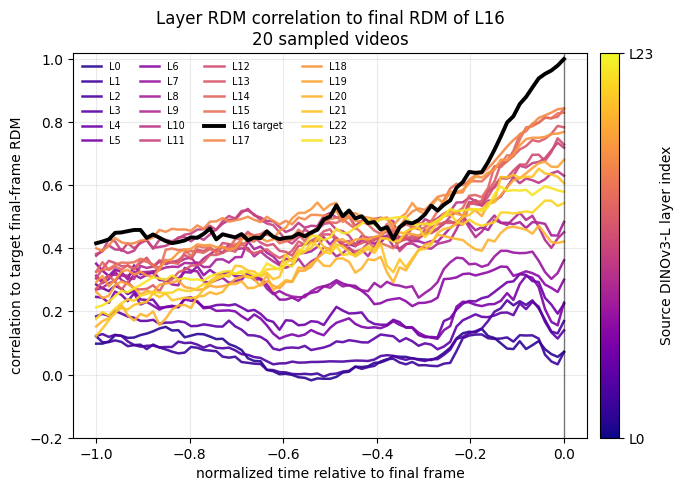

In [115]:
cmap = plt.cm.plasma
colors = cmap(np.linspace(0.05, 0.95, len(layers)))

fig, ax = plt.subplots(figsize=(8, 5))
for layer, color in zip(layers, colors):
    is_target = layer == target_rdm_layer
    ax.plot(
        rdm_normalized_time_to_final,
        cross_layer_rdm_corr_to_target_final[layer],
        color='black' if is_target else color,
        linewidth=2.8 if is_target else 1.8,
        alpha=1.0 if is_target else 0.9,
        label=f'{short_layer_name(layer)} target' if is_target else short_layer_name(layer),
        zorder=3 if is_target else 2,
    )

ax.axvline(0, color='black', linewidth=1, alpha=0.5)
ax.set_title(f'Layer RDM correlation to final RDM of {short_layer_name(target_rdm_layer)}\n{len(rdm_video_paths)} sampled videos')
ax.set_xlabel('normalized time relative to final frame')
ax.set_ylabel('correlation to target final-frame RDM')
ax.set_ylim(-0.2, 1.02)
ax.grid(True, alpha=0.25)

norm = plt.Normalize(vmin=0, vmax=len(layers) - 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Source DINOv3-L layer index')
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels([short_layer_name(layers[0]), short_layer_name(layers[-1])])

ax.legend(ncol=4, fontsize=7, frameon=False, loc='upper left')
plt.show()


## RDM autocorrelation lagplots

The vectorized RDMs form a time series for each layer. This computes the full RDM autocorrelation matrix and the diagonal-averaged lagplot with `TimeSeries.autocorr()`, matching the raw-activation autocorrelation section above.

In [92]:
rdm_autocorr_by_layer = {}
rdm_lagplot_by_layer = {}

for layer in layers:
    rdm_ts = rdm_timeseries_by_layer[layer]
    rdm_array = np.stack(rdm_ts.array, axis=0)  # time x RDM-pairs
    rdm_vector_ts = TimeSeries(rdm_array.T, fs=RDM_N_TIMEPOINTS)
    max_lag = max(1, min(LAGPLOT_MAX_LAG, len(rdm_vector_ts) - 1))
    ac_mat, ac_decay = rdm_vector_ts.autocorr(max_lag=max_lag)
    rdm_autocorr_by_layer[layer] = ac_mat
    rdm_lagplot_by_layer[layer] = ac_decay

example_layer = layers[-1]
print(example_layer, rdm_autocorr_by_layer[example_layer].shape, rdm_lagplot_by_layer[example_layer].shape)


15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of datapoints used to compute extreme offsets is < than 10
15:51:02 - The number of dat

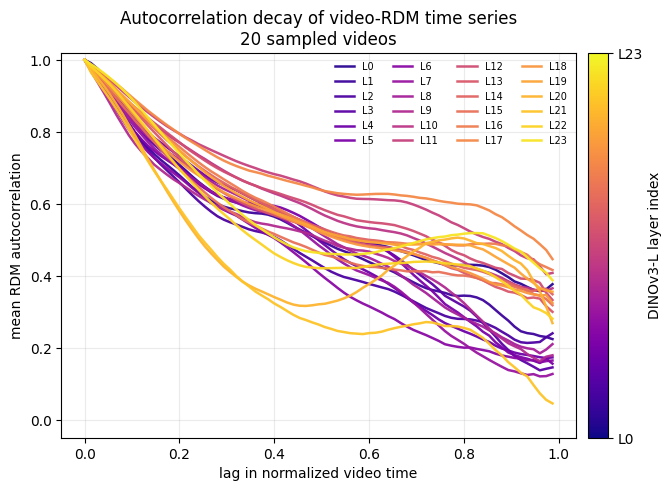

In [93]:
cmap = plt.cm.plasma
colors = cmap(np.linspace(0.05, 0.95, len(layers)))

fig, ax = plt.subplots(figsize=(8, 5))
for layer, color in zip(layers, colors):
    decay = rdm_lagplot_by_layer[layer]
    lag_normalized_time = np.arange(len(decay)) / RDM_N_TIMEPOINTS
    ax.plot(
        lag_normalized_time,
        decay,
        color=color,
        linewidth=1.8,
        alpha=0.95,
        label=short_layer_name(layer),
    )

ax.set_title(f'Autocorrelation decay of video-RDM time series\n{len(rdm_video_paths)} sampled videos')
ax.set_xlabel('lag in normalized video time')
ax.set_ylabel('mean RDM autocorrelation')
ax.set_ylim(-0.05, 1.02)
ax.grid(True, alpha=0.25)

norm = plt.Normalize(vmin=0, vmax=len(layers) - 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('DINOv3-L layer index')
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels([short_layer_name(layers[0]), short_layer_name(layers[-1])])

ax.legend(ncol=4, fontsize=7, frameon=False, loc='upper right')
plt.show()


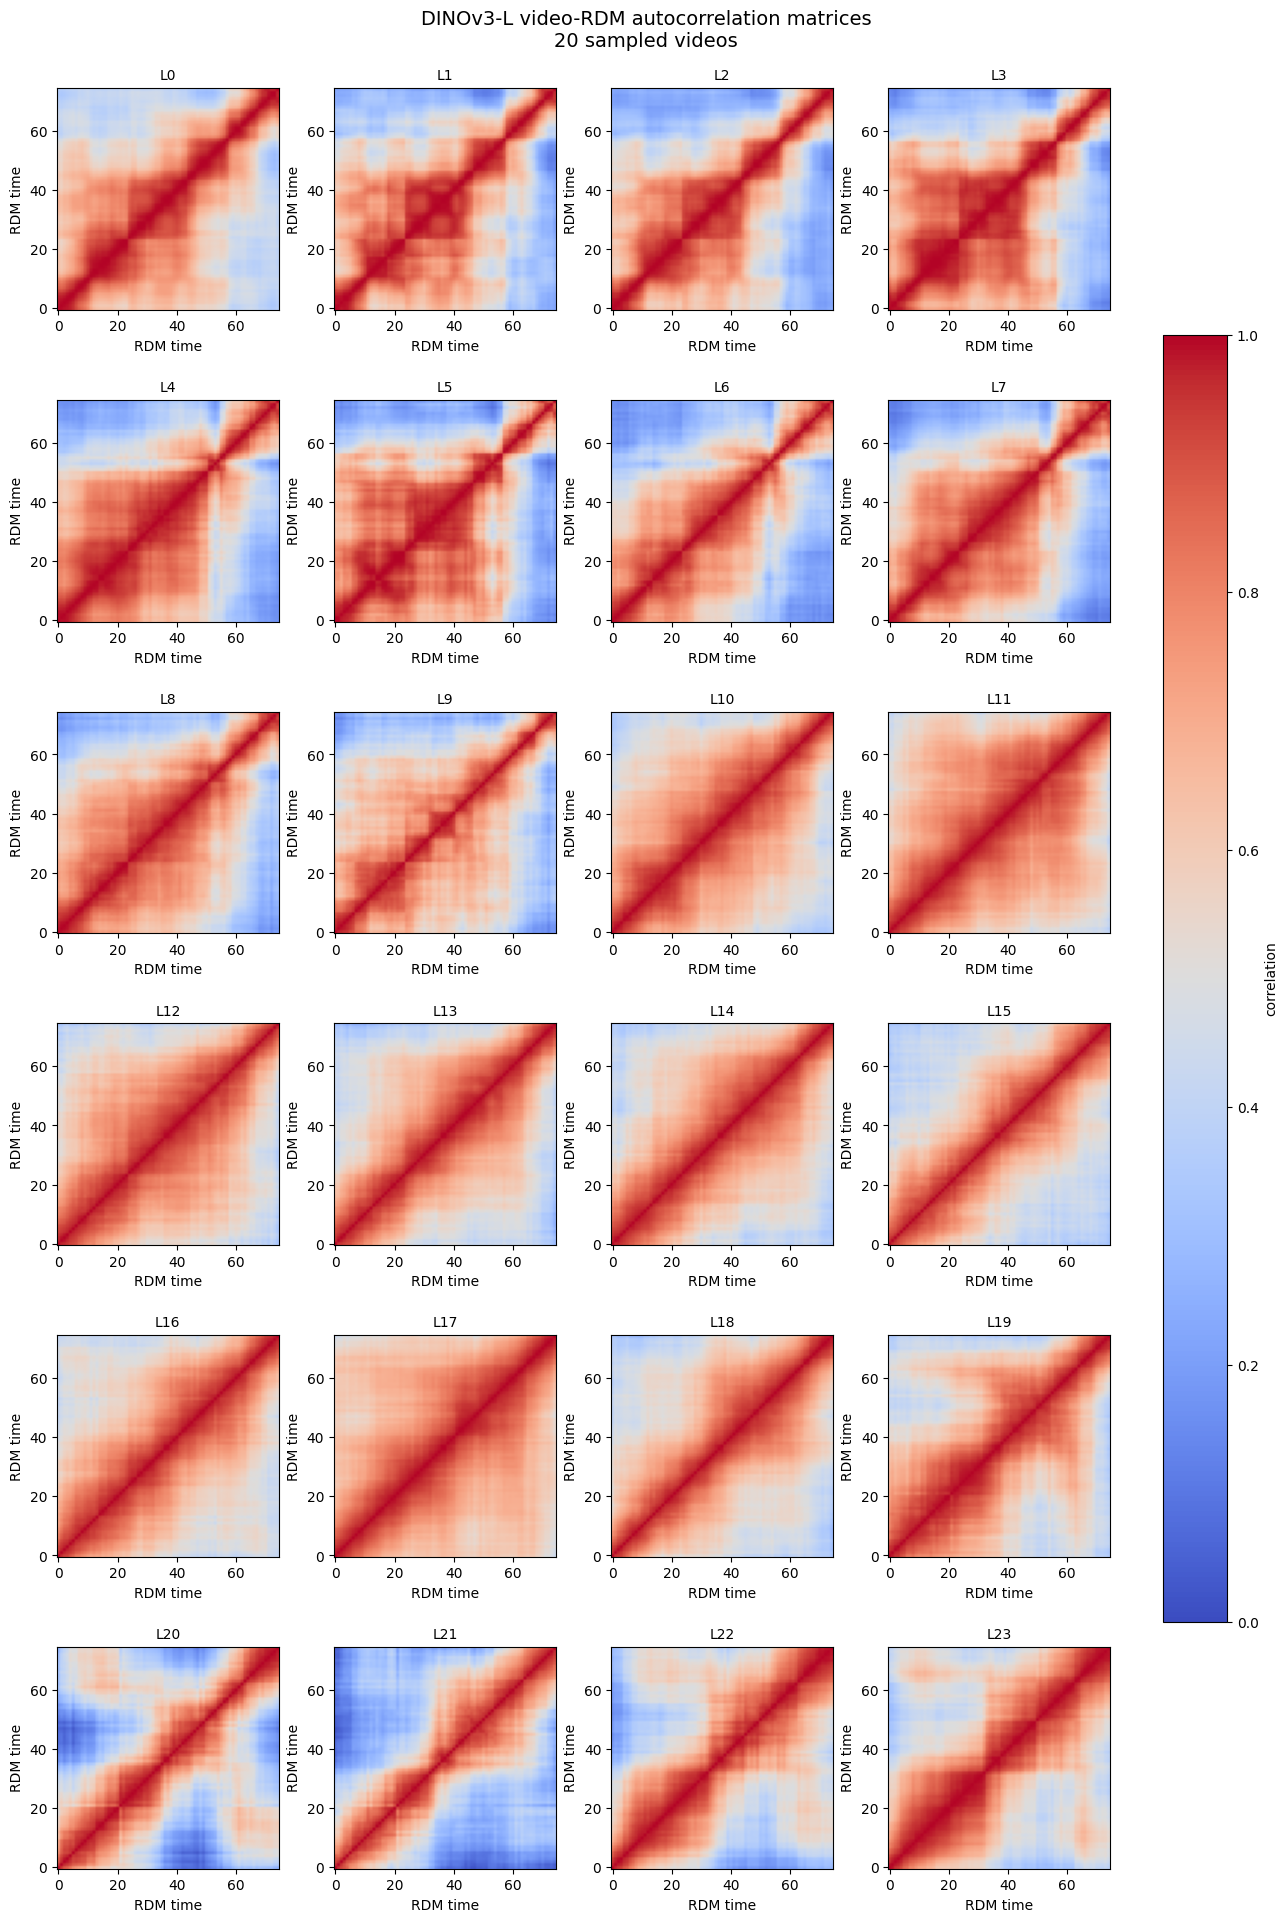

In [94]:
n_layers = len(layers)
ncols = 4
nrows = math.ceil(n_layers / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), constrained_layout=True)
axes = np.asarray(axes).ravel()

im = None
for ax, layer in zip(axes, layers):
    im = ax.imshow(rdm_autocorr_by_layer[layer], vmin=0, vmax=1, cmap='coolwarm', origin='lower')
    ax.set_title(short_layer_name(layer), fontsize=10)
    ax.set_xlabel('RDM time')
    ax.set_ylabel('RDM time')

for ax in axes[n_layers:]:
    ax.axis('off')

fig.suptitle(f'DINOv3-L video-RDM autocorrelation matrices\n{len(rdm_video_paths)} sampled videos', fontsize=14)
fig.colorbar(im, ax=axes[:n_layers], shrink=0.7, label='correlation')
plt.show()


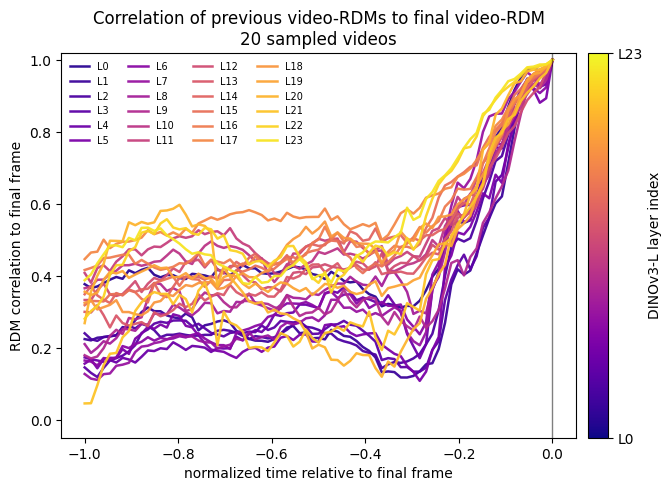

In [89]:
cmap = plt.cm.plasma
colors = cmap(np.linspace(0.05, 0.95, len(layers)))

fig, ax = plt.subplots(figsize=(8, 5))
for layer, color in zip(layers, colors):
    ax.plot(
        rdm_normalized_time_to_final,
        rdm_corr_to_final_by_layer[layer],
        color=color,
        linewidth=1.8,
        alpha=0.95,
        label=short_layer_name(layer),
    )

ax.axvline(0, color='black', linewidth=1, alpha=0.5)
ax.set_title(f'Correlation of previous video-RDMs to final video-RDM\n{len(rdm_video_paths)} sampled videos')
ax.set_xlabel('normalized time relative to final frame')
ax.set_ylabel('RDM correlation to final frame')
ax.set_ylim(-0.05, 1.02)


norm = plt.Normalize(vmin=0, vmax=len(layers) - 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('DINOv3-L layer index')
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels([short_layer_name(layers[0]), short_layer_name(layers[-1])])

ax.legend(ncol=4, fontsize=7, frameon=False, loc='upper left')
plt.show()


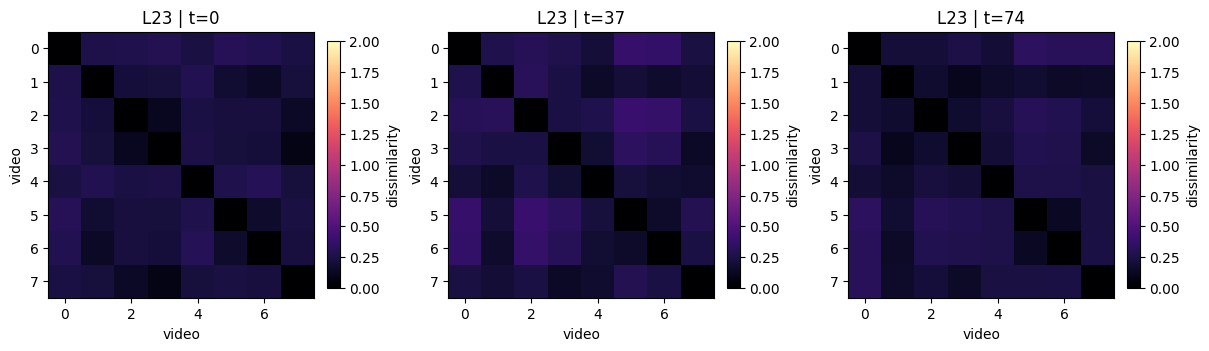

In [78]:
selected_rdm_layer = layers[-1]
time_indices_to_show = [0, RDM_N_TIMEPOINTS // 2, RDM_N_TIMEPOINTS - 1]

fig, axes = plt.subplots(1, len(time_indices_to_show), figsize=(4 * len(time_indices_to_show), 3.5), constrained_layout=True)
if len(time_indices_to_show) == 1:
    axes = [axes]

vmax = 2 if RDM_METRIC == 'correlation' else None
for ax, t_idx in zip(axes, time_indices_to_show):
    rdm_square = squareform(rdm_timeseries_by_layer[selected_rdm_layer].array[t_idx])
    im = ax.imshow(rdm_square, cmap='magma', vmin=0, vmax=vmax)
    ax.set_title(f'{short_layer_name(selected_rdm_layer)} | t={t_idx}')
    ax.set_xlabel('video')
    ax.set_ylabel('video')
    fig.colorbar(im, ax=ax, shrink=0.8, label='dissimilarity')

plt.show()


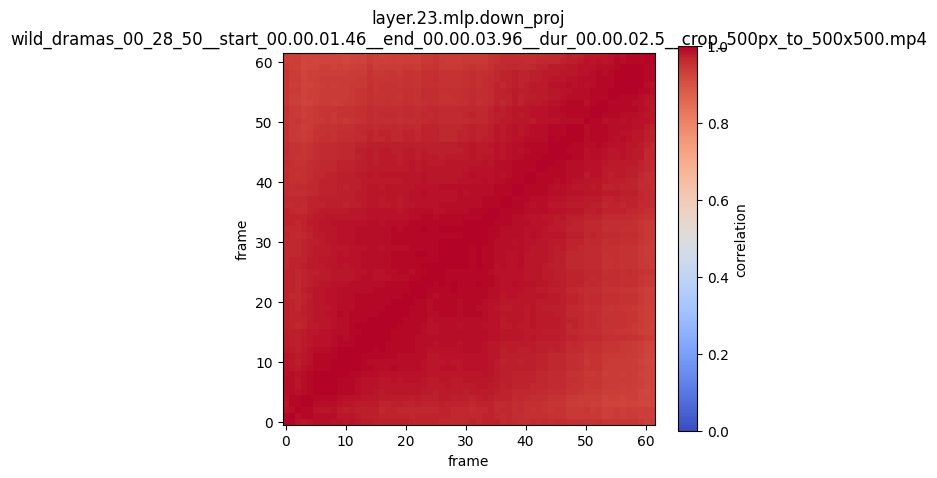

In [62]:
selected_layer = layers[-1]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(autocorr_by_layer[selected_layer], vmin=0, vmax=1, cmap='coolwarm', origin='lower')
ax.set_title(f'{selected_layer}\n{video_path.name}')
ax.set_xlabel('frame')
ax.set_ylabel('frame')
fig.colorbar(im, ax=ax, label='correlation')
plt.show()

## Optional: save matrices and derived curves


In [ ]:
OUTPUT_DIR.mkdir(exist_ok=True)
safe_video_stem = video_path.stem.replace(' ', '_')

npz_payload = {
    f'layer_{idx:02d}': autocorr_by_layer[layer]
    for idx, layer in enumerate(layers)
}
for idx, layer in enumerate(layers):
    npz_payload[f'layer_{idx:02d}_lagplot'] = lagplot_by_layer[layer]
    npz_payload[f'layer_{idx:02d}_corr_to_last'] = corr_to_last_by_layer[layer]
npz_payload['time_offsets_to_last'] = time_offsets_to_last

if 'cross_layer_rdm_corr_to_target_final' in globals():
    npz_payload['cross_layer_rdm_target_layer'] = np.array(target_rdm_layer, dtype=object)
    npz_payload['cross_layer_rdm_target_layer_index'] = np.array(CROSS_LAYER_TARGET_LAYER_INDEX)
    npz_payload['cross_layer_rdm_target_final_rdm'] = target_final_rdm
    for idx, layer in enumerate(layers):
        npz_payload[f'layer_{idx:02d}_cross_rdm_corr_to_target_final'] = cross_layer_rdm_corr_to_target_final[layer]

if 'rdm_corr_to_final_by_layer' in globals():
    for idx, layer in enumerate(layers):
        npz_payload[f'layer_{idx:02d}_sample_video_rdm_corr_to_final'] = rdm_corr_to_final_by_layer[layer]
        npz_payload[f'layer_{idx:02d}_sample_video_rdm_timeseries'] = np.stack(rdm_timeseries_by_layer[layer].array, axis=0)
        if 'rdm_lagplot_by_layer' in globals():
            npz_payload[f'layer_{idx:02d}_sample_video_rdm_autocorr'] = rdm_autocorr_by_layer[layer]
            npz_payload[f'layer_{idx:02d}_sample_video_rdm_lagplot'] = rdm_lagplot_by_layer[layer]
    npz_payload['rdm_sample_video_paths'] = np.array([str(p) for p in rdm_video_paths], dtype=object)
    npz_payload['rdm_sampled_frame_indices'] = np.array([rdm_sampled_frame_indices[str(p)] for p in rdm_video_paths], dtype=object)
    npz_payload['rdm_normalized_time_to_final'] = rdm_normalized_time_to_final

npz_payload['layer_names'] = np.array(layers, dtype=object)
npz_payload['video_path'] = np.array(str(video_path), dtype=object)
npz_payload['sampling_rate'] = np.array(sampling_rate)

out_path = OUTPUT_DIR / f'{safe_video_stem}_dinov3l_autocorr.npz'
np.savez_compressed(out_path, **npz_payload)
print(f'Saved matrices and curves to {out_path}')
